# SET-A

# Q1

In [8]:
import nltk
import re
import heapq
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/tycs18/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/tycs18/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
text = """Artificial Intelligence is transforming the world. It is used in healthcare, education, and finance. 
AI helps doctors detect disease early. Many companies use AI to improve customer service. However, there are concerns 
about privacy and job loss"""

formatted_text = re.sub('[^a-zA-Z]',' ', text)
#print(formatted_text)
formatted_text = formatted_text.lower()
#print(formatted_text)

words = word_tokenize(formatted_text)
#words

stop_words = set(stopwords.words("english"))
stop_words


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [10]:
word_frequencies = {}
for word in words:
    if word not in stop_words:
        word_frequencies[word] = word_frequencies.get(word,0)+1
word_frequencies


{'artificial': 1,
 'intelligence': 1,
 'transforming': 1,
 'world': 1,
 'used': 1,
 'healthcare': 1,
 'education': 1,
 'finance': 1,
 'ai': 2,
 'helps': 1,
 'doctors': 1,
 'detect': 1,
 'disease': 1,
 'early': 1,
 'many': 1,
 'companies': 1,
 'use': 1,
 'improve': 1,
 'customer': 1,
 'service': 1,
 'however': 1,
 'concerns': 1,
 'privacy': 1,
 'job': 1,
 'loss': 1}

In [11]:
maximum_freq = max(word_frequencies.values())
for word in word_frequencies:
    word_frequencies[word] /= maximum_freq

maximum_freq

2

In [12]:
sentences = sent_tokenize(text)
sentence_scores = {}

for sentence in sentences:
    for word in word_tokenize(sentence.lower()):
        if word in word_frequencies:
            sentence_scores[sentence] = sentence_scores.get(sentence, 0) + word_frequencies[word]

sentence_scores


{'Artificial Intelligence is transforming the world.': 2.0,
 'It is used in healthcare, education, and finance.': 2.0,
 'AI helps doctors detect disease early.': 3.5,
 'Many companies use AI to improve customer service.': 4.0,
 'However, there are concerns \nabout privacy and job loss': 2.5}

In [13]:
summary_sentences = heapq.nlargest(2,sentence_scores, key = sentence_scores.get)
summary = " ".join(summary_sentences)
print(summary)

Many companies use AI to improve customer service. AI helps doctors detect disease early.


# Q2

[nltk_data] Downloading package stopwords to /home/tycs18/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


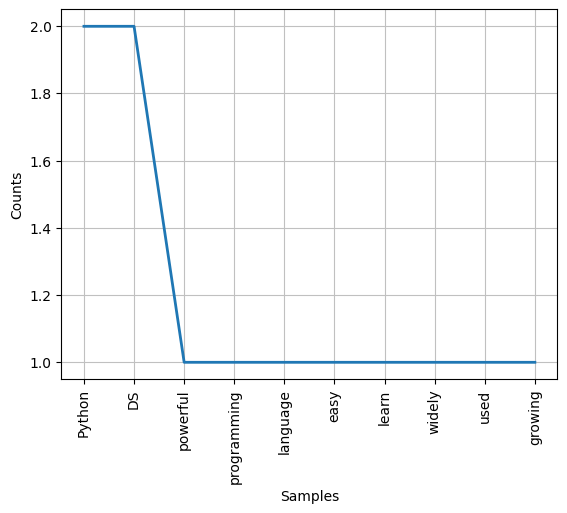

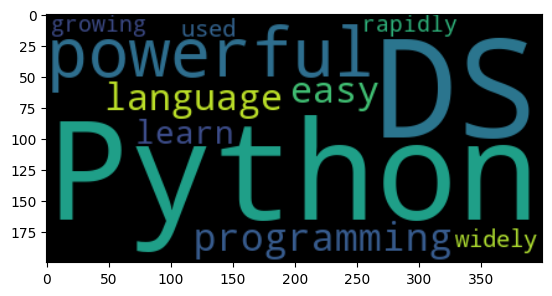

In [14]:
import nltk
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords')


text = """Python is a powerful programming language. Python is easy to learn & widely used in DS. DS is growing rapidly."""

Sentences = sent_tokenize(text)
words = word_tokenize(text)

filtered_words = [word for word in words if word.lower() not in stop_words and word.isalpha()]

freq_dist = FreqDist(filtered_words)
freq_dist.plot(10)
plt.show()

wordcloud = WordCloud(background_color = 'black').generate(" ".join(filtered_words))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.show()


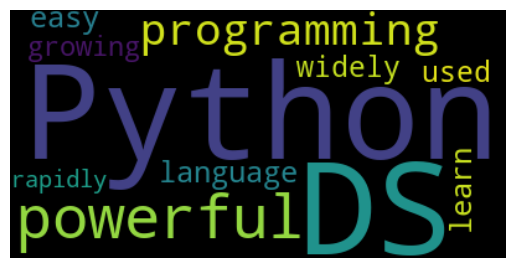

In [15]:

wordcloud = WordCloud(background_color = 'black').generate(" ".join(filtered_words))

plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis("off")
plt.show()

# Q3

In [16]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/tycs18/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
sia = SentimentIntensityAnalyzer()

reviews = ["I purchased headphones online. I am very happy with the product",
           "I saw the movie yesterday. The Animation was really good but script was OK",
           "I enjoy listening to music",
           "I take a walk in the park everyday"
          ]

for review in reviews:
    score = sia.polarity_scores(review)
    print(review)
    print(score)

I purchased headphones online. I am very happy with the product
{'neg': 0.0, 'neu': 0.667, 'pos': 0.333, 'compound': 0.6115}
I saw the movie yesterday. The Animation was really good but script was OK
{'neg': 0.0, 'neu': 0.647, 'pos': 0.353, 'compound': 0.7181}
I enjoy listening to music
{'neg': 0.0, 'neu': 0.484, 'pos': 0.516, 'compound': 0.4939}
I take a walk in the park everyday
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


# SET B

# Q2

In [18]:
import pandas as pd

data = pd.read_csv("covid_2021_1.csv")
data

,query,url,title,upload_date,channel,views,likes,dislikes,comment_count,comment_text,comment_author,comment_date,comment_likes,DATE
0,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,OMG 😍💋 💝💖❤️,Brendan Eric,2021-01-01T09:23:59Z,0.0,2021-01-01 09:04:16+00:00
1,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,I love my Indian Mumbai me welcome,Bhallesingh Rathore rathore,2021-01-01T09:06:51Z,1.0,2021-01-01 09:04:16+00:00
2,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,What about indian vaccine?,Kudip singh hong kong.,2021-02-03T08:17:14Z,0.0,2021-01-01 09:04:16+00:00
3,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,2:32 I like that😍💋 💝💖❤️,Bo Brice,2021-01-01T09:55:34Z,0.0,2021-01-01 09:04:16+00:00
4,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=dwMWM1F7NMI,Growing Number Of Americans Going Hungry Durin...,2021-01-01T11:59:49Z,NBC News,74546,874,62,601,And all the rich companies that have profited ...,Poppy Jalto,2021-01-01T13:17:56Z,93.0,2021-01-01 11:59:49+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2721,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=WvYwX9WMzGM,After Getting COVID Vaccine | Auburn Medical G...,2021-01-05T19:54:45Z,Auburn Medical Group,2129,50,4,12,What do think about people not what the needle...,judith marshall,2021-01-13T01:26:29Z,1.0,2021-01-05 19:54:45+00:00
2722,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=2ewylBbJhxs,"""Nobody Said It's A Trial"": A New Covid Vaccin...",2021-01-05T20:16:11Z,NDTV,12822,337,23,95,They are checking it on poor ppl😂,Mohsinmufasa Khan,2021-01-23T19:38:38Z,0.0,2021-01-05 20:16:11+00:00
2723,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=2ewylBbJhxs,"""Nobody Said It's A Trial"": A New Covid Vaccin...",2021-01-05T20:16:11Z,NDTV,12822,337,23,95,Aapke sath ek chota sa prank kiya gaya hai. Ha...,Tomato Sauce,2021-01-05T20:46:30Z,3.0,2021-01-05 20:16:11+00:00
2724,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=2ewylBbJhxs,"""Nobody Said It's A Trial"": A New Covid Vaccin...",2021-01-05T20:16:11Z,NDTV,12822,337,23,95,I saw another video where the two people they ...,Sneha,2021-01-09T21:41:16Z,0.0,2021-01-05 20:16:11+00:00


In [20]:
data = data.dropna(subset = ['comment_text'])
nltk.download('vader_lexicon')
comments = data['comment_text']

positive = 0
negative = 0
netural = 0

for comment in comments :
    score = sia.polarity_scores(comment)
    if score['compound'] >= 0.05:
        positive += 1
    elif score['compound'] <= 0.05:
        negative += 1
    else :
        neutral += 1

total = positive + negative + netural
print("Positive % : ",100 * positive/total)
print("Negative % : ", 100*negative/total)
print("Neutral % : ", 100*netural/total)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/tycs18/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Positive % :  42.223037417461484
Negative % :  57.776962582538516
Neutral % :  0.0


# Q3

In [35]:
data = pd.read_csv("INvideos.csv", engine="python", on_bad_lines="skip")
data

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,V2VquEl3zzE,17.17.11,Madras Central Gopi'ஐ ரசிப்பேன் - Seeman | Nau...,Black Sheep,24,2017-11-14T09:31:39.000Z,"seeman|""seeman interview""|""madras central""|""pa...",400000,12534,584,1206,https://i.ytimg.com/vi/V2VquEl3zzE/default.jpg,False,False,False,Seeman says his views and opinions about onlin...
703,nNhclTpN_w0,17.17.11,Maruvaarthai - Megha Akash Version | Enai Noki...,BehindwoodsTV,24,2017-11-15T12:11:32.000Z,"Maruvaarthai|""Dhanush""|""Megha Akash""|""Ramaguru...",127334,2845,109,264,https://i.ytimg.com/vi/nNhclTpN_w0/default.jpg,False,False,False,"In this episode of The Untitled Show, Actress ..."
704,Fvg3EkAp15E,17.17.11,#SirPost - Letter To CM (Chinna Mudhalvar) | ...,Smile Settai,23,2017-11-14T11:47:39.000Z,"Sir post|""EPS TRoll""|""Smile settai letter to E...",201800,12508,229,1116,https://i.ytimg.com/vi/Fvg3EkAp15E/default.jpg,False,False,False,#SirPost.. This time our Letter is to Our Hono...
705,Q_FAO1ZNKgo,17.17.11,Stephen Has A Drink For Trump... Or Tries To,The Late Show with Stephen Colbert,24,2017-11-16T08:35:01.000Z,"The Late Show|""Stephen Colbert""|""Colbert""|""Lat...",597836,10079,324,855,https://i.ytimg.com/vi/Q_FAO1ZNKgo/default.jpg,False,False,False,President Trump took a break mid-speech Wednes...


Total views :  545735840
Total Likes :  13215814
Total Dislikes :  663218
Total comments :  1385373
        video_id trending_date  \
691  sEmUj8pm-b4      17.17.11   

                                                title channel_title  \
691  16 November, 2017 Prelim Booster News Discussion      only ias   

     category_id              publish_time    tags  views  likes  dislikes  \
691           27 2017-11-16 07:39:59+00:00  [none]  18747      0         0   

     comment_count                                  thumbnail_link  \
691              0  https://i.ytimg.com/vi/sEmUj8pm-b4/default.jpg   

     comments_disabled  ratings_disabled  video_error_or_removed  \
691               True              True                   False   

                                           description  year  
691  Subscribe to http://www.onlyias.com/\n\nLike u...  2017  


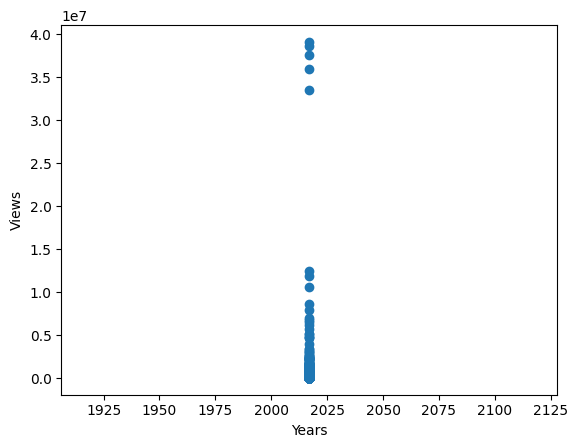

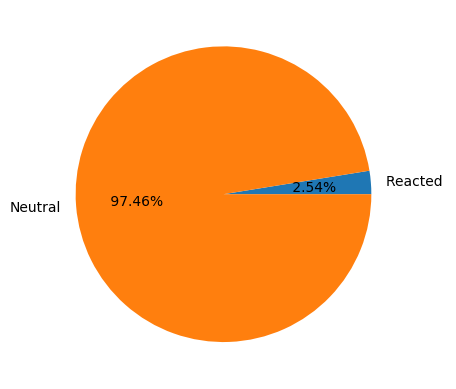

In [40]:
data = data.dropna()
print("Total views : ",data['views'].sum())
print("Total Likes : ", data['likes'].sum())

print("Total Dislikes : ",data['dislikes'].sum())
print("Total comments : ",data['comment_count'].sum())

print(data.sort_values(by = 'likes').head(1))

data['publish_time'] = pd.to_datetime(data['publish_time'])
data['year'] = data['publish_time'].dt.year

plt.scatter(data['year'],data['views'])
plt.xlabel("Years")
plt.ylabel("Views")
plt.show()

reacted = data['likes'].sum() + data['dislikes'].sum()
neutral = data['views'].sum() - reacted

plt.pie([reacted, neutral], labels = ['Reacted ', 'Neutral'],autopct = '% 1.2f%%')
plt.show()